# 🚀 Phân tích Benchmark Face Recognition (Phiên Bản LOCAL PC - Pretrained)
Chào mừng bạn chạy trực tiếp trên máy bàn của mình! Do sử dụng tài nguyên ngay tại nhà, bạn không cần phải phiền hà Upload file gì cả.

In [5]:
import sys
# Nếu bạn mới cài thư viện scikit-learn thì nên cập nhật qua lệnh này (bỏ dấu # ở dưới để chạy)
# %pip install --upgrade scikit-learn onnxruntime mediapipe opencv-python matplotlib tqdm

## 1. Tải LFW qua thư viện Scikit-Learn 
Dữ liệu tải về sẽ được hệ thống âm thầm lưu tại thư mục cá nhân `C:\Users\Admin\scikit_learn_data` của Windows.

In [6]:
from sklearn.datasets import fetch_lfw_people
import numpy as np

print("Đang lấy kho ảnh LFW về máy tính của bạn qua S3 Mirror (~200MB)...")
lfw_people = fetch_lfw_people(min_faces_per_person=2, color=True, resize=1.0)
print("Tải hoàn tất!")
print(f"Tổng số ảnh hiện có: {len(lfw_people.images)}")
print(f"Tổng số người có từ 2 ảnh trở lên: {len(lfw_people.target_names)}")

Đang lấy kho ảnh LFW về máy tính của bạn qua S3 Mirror (~200MB)...
Tải hoàn tất!
Tổng số ảnh hiện có: 9164
Tổng số người có từ 2 ảnh trở lên: 1680


## 2. Dựng luồng Model Local (Sử dụng MediaPipe Tasks API)

In [7]:
import urllib.request
import os

FL_URL = "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task"
FL_PATH = "face_landmarker.task"
# Tải tự động quả tim của hệ thống dò mặt MediaPipe về chung thư mục
if not os.path.exists(FL_PATH):
    print("Đang tải MediaPipe Face Landmarker Model để tìm 5 điểm mắt mũi...")
    urllib.request.urlretrieve(FL_URL, FL_PATH)
    print("Tải hoàn tất!")

import cv2
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
import onnxruntime as ort

# Gọi thẳng cấu trúc mạnh mẽ nhất của MediaPipe v0.10+
base_options = mp_python.BaseOptions(model_asset_path=FL_PATH)
options = vision.FaceLandmarkerOptions(base_options=base_options,
                                       running_mode=vision.RunningMode.IMAGE,
                                       num_faces=1)
landmarker = vision.FaceLandmarker.create_from_options(options)

# Tọa độ lý tưởng của ArcFace v4
SRC_PTS = np.array([
    [38.2946, 51.6963], [73.5318, 51.5014],
    [56.0252, 71.7366],
    [41.5493, 92.3655], [70.7299, 92.2041]
], dtype=np.float32)

def get_lm5(image_rgb):
    h, w = image_rgb.shape[:2]
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
    res = landmarker.detect(mp_img)
    if not res.face_landmarks: return None
    lms = res.face_landmarks[0]
    pts = []
    for idx in [468, 473, 1, 61, 291]:
        pts.append([lms[idx].x * w, lms[idx].y * h])
    return np.array(pts, dtype=np.float32)

def get_embedding(rgb_img, session, input_name):
    lm5 = get_lm5(rgb_img)
    if lm5 is None: return None
    tform = cv2.estimateAffinePartial2D(lm5, SRC_PTS, method=cv2.LMEDS)[0]
    if tform is None: return None
    aligned = cv2.warpAffine(rgb_img, tform, (112, 112))
    blob = cv2.dnn.blobFromImage(cv2.cvtColor(aligned, cv2.COLOR_RGB2BGR), 1.0/127.5, (112, 112), (127.5, 127.5, 127.5), swapRB=False)
    emb = session.run(None, {input_name: blob})[0][0]
    return emb / np.linalg.norm(emb)

## 3. Trích xuất Embeddings trên LFW bằng ổ đĩa Cục Bộ

In [8]:
# Dùng tqdm chuẩn thay vì tqdm.notebook để không bị lỗi Missing Ipywidgets trên VS Code
from tqdm.auto import tqdm
import os

# SIÊU TỰ ĐỘNG: Tìm Model Pretrained w600k_r50 chuẩn của Thế Giới
home_path = os.path.expanduser('~')
MODEL_PATH = os.path.join(home_path, '.insightface', 'models', 'buffalo_l', 'w600k_r50.onnx')

if not os.path.exists(MODEL_PATH):
    print(f"⚠️ LỖI CHÍ MẠNG: Bạn vẫn bị thiếu model ở chỗ {MODEL_PATH}! Có chăng là bạn lỡ xóa hoặc đổi tên nó?")
else:
    print(f"✅ TÌM THẤY RỒI: Máy đã câu thẳng vào {MODEL_PATH}")
    # Nếu máy bạn cài onnxruntime-gpu thì nó sẽ bay cực khủng!
    providers = ['CUDAExecutionProvider', 'CPUExecutionProvider']
    session = ort.InferenceSession(MODEL_PATH, providers=providers)
    input_name = session.get_inputs()[0].name

    embeddings = {}
    valid = 0

    print("Hành trình trích xuất đặc trưng LFW bắt đầu...")
    for i in tqdm(range(len(lfw_people.images)), desc="Đang nhai ảnh LFW"):
        img_array = lfw_people.images[i]
        if img_array.max() <= 1.0:
            img = (img_array * 255.0).astype(np.uint8)
        else:
            img = img_array.astype(np.uint8)
            
        label = lfw_people.target_names[lfw_people.target[i]]
        emb = get_embedding(img, session, input_name)
        
        if emb is not None:
            if label not in embeddings:
                embeddings[label] = []
            embeddings[label].append(emb)
            valid += 1

    print(f"Trích xuất xong vẻ vang! Lấy được đặc trưng của {valid} người trên tổng số khuôn mặt.")

✅ TÌM THẤY RỒI: Máy đã câu thẳng vào C:\Users\Admin\.insightface\models\buffalo_l\w600k_r50.onnx
Hành trình trích xuất đặc trưng LFW bắt đầu...


Đang nhai ảnh LFW: 100%|██████████| 9164/9164 [19:38<00:00,  7.77it/s]

Trích xuất xong vẻ vang! Lấy được đặc trưng của 9078 người trên tổng số khuôn mặt.


## 4. Benchmark Báo Cáo EER, Optimal Threshold, FAR & FRR

📊 KẾT QUẢ BENCHMARK LFW - MODEL PRETRAINED THẾ GIỚI MẶC ĐỊNH
Số Cặp Cùng Người Đo Được  : 238335 pairs
Số Cặp Khác Người Đo Được  : 8803217 pairs
💎 EER (Lỗi Nhận Diện)      : 0.053%
📏 Ngưỡng Threshold Tối Ưu : 0.234

📸 ĐÃ LƯU TỰ ĐỘNG BẢN BÁO CÁO NHỎ VÀO THƯ MỤC DOCS!


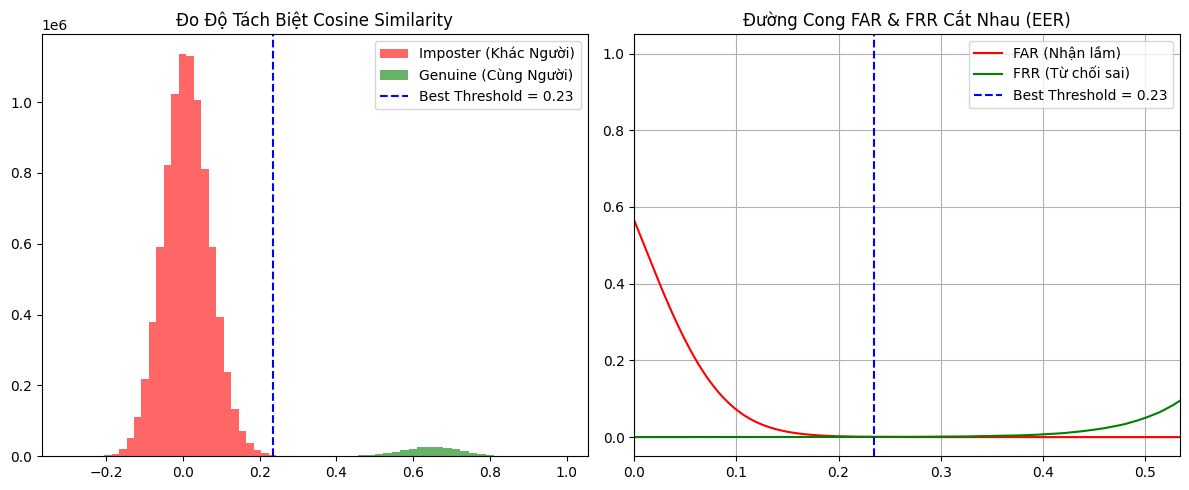

In [9]:
import itertools
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore') # Tắt mấy cảnh báo lặt vặt của Numpy/Mathplot

def plot_benchmark():
    gen_scores, imp_scores = [], []
    p_list = [p for p in embeddings.keys() if len(embeddings[p]) >= 2]
    
    # Genuine Pairs
    for p in p_list:
        for e1, e2 in itertools.combinations(embeddings[p], 2):
            gen_scores.append(float(np.dot(e1, e2)))
            
    # Imposter Pairs (Khống chế lại không là nó cấp số nhân lên hàng tỷ cặp thì CPU cháy khét)
    for i in range(len(p_list)):
        num_pairs = min(50, len(embeddings[p_list[i]]))
        for e1 in embeddings[p_list[i]][:num_pairs]:
            for j in range(i+1, len(p_list)):
                for e2 in embeddings[p_list[j]][:1]:
                    imp_scores.append(float(np.dot(e1, e2)))

    gen_scores = np.array(gen_scores)
    imp_scores = np.array(imp_scores)
    
    thresholds = np.linspace(0.0, 1.0, 1000)
    far = np.array([np.sum(imp_scores >= t) / len(imp_scores) for t in thresholds])
    frr = np.array([np.sum(gen_scores < t) / len(gen_scores) for t in thresholds])
    
    diff = np.abs(far - frr)
    min_idx = np.argmin(diff)
    eer = (far[min_idx] + frr[min_idx]) / 2
    optimal_th = thresholds[min_idx]

    print("="*50)
    print("📊 KẾT QUẢ BENCHMARK LFW - MODEL PRETRAINED THẾ GIỚI MẶC ĐỊNH")
    print(f"Số Cặp Cùng Người Đo Được  : {len(gen_scores)} pairs")
    print(f"Số Cặp Khác Người Đo Được  : {len(imp_scores)} pairs")
    print(f"💎 EER (Lỗi Nhận Diện)      : {eer*100:.3f}%")
    print(f"📏 Ngưỡng Threshold Tối Ưu : {optimal_th:.3f}")
    print("="*50)

    plt.figure(figsize=(12, 5))
    
    # Biểu đồ đồi chéo
    plt.subplot(1, 2, 1)
    plt.hist(imp_scores, bins=50, alpha=0.6, color='red', label='Imposter (Khác Người)')
    plt.hist(gen_scores, bins=50, alpha=0.6, color='green', label='Genuine (Cùng Người)')
    plt.axvline(optimal_th, color='blue', linestyle='dashed', label=f'Best Threshold = {optimal_th:.2f}')
    plt.title('Đo Độ Tách Biệt Cosine Similarity')
    plt.legend()
    
    # Biểu đồ mỏ neo chéo
    plt.subplot(1, 2, 2)
    plt.plot(thresholds, far, 'r-', label='FAR (Nhận lầm)')
    plt.plot(thresholds, frr, 'g-', label='FRR (Từ chối sai)')
    plt.axvline(optimal_th, color='blue', linestyle='dashed', label=f'Best Threshold = {optimal_th:.2f}')
    plt.xlim([max(0.0, optimal_th - 0.3), min(1.0, optimal_th + 0.3)])
    plt.ylim([-0.05, 1.05])
    plt.title('Đường Cong FAR & FRR Cắt Nhau (EER)')
    plt.legend(); plt.grid(True)
    plt.tight_layout()
    
    # LƯU ẢNH VÀ THÔNG SỐ VÀO THƯ MỤC DOCS NHƯ YÊU CẦU
    os.makedirs(r"e:\Workspace\detect\docs", exist_ok=True)
    plt.savefig(r"e:\Workspace\detect\docs\benchmark_lfw_v4.png", dpi=300, bbox_inches='tight')
    with open(r"e:\Workspace\detect\docs\benchmark_metrics.txt", "w", encoding="utf-8") as f:
        f.write("KẾT QUẢ BENCHMARK LFW - MODEL PRETRAINED\n")
        f.write(f"Genuine Pairs: {len(gen_scores)}\n")
        f.write(f"Imposter Pairs: {len(imp_scores)}\n")
        f.write(f"EER: {eer*100:.3f}%\n")
        f.write(f"Optimal Threshold: {optimal_th:.3f}\n")
    print("\n📸 ĐÃ LƯU TỰ ĐỘNG BẢN BÁO CÁO NHỎ VÀO THƯ MỤC DOCS!")
    
    plt.show()

if 'embeddings' in globals() and len(embeddings) > 0:
    plot_benchmark()